In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
print(df.shape)

(10000, 14)


In [4]:
df.head()
#print(df.shape)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
 df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace = True)

In [11]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

In [13]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [14]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

In [15]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [16]:
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=1)

In [18]:
X_train.shape

(8000, 11)

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [20]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [21]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

2026-05-29 14:45:57.385497: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780065957.683872      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780065957.758851      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780065958.349561      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780065958.349610      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780065958.349614      58 computation_placer.cc:177] computation placer alr

In [22]:
model = Sequential()

# model.add(Dense(3, activation = 'sigmoid', input_dim = 11))
model.add(Dense(11, activation = 'relu', input_dim = 11))
model.add(Dense(11, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-05-29 14:46:15.059633: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# model.compile(loss = 'binary_crossentropy', optimizer = 'Adam')
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [25]:
# model.fit(X_train_scaled, y_train, epochs = 10)
history = model.fit(X_train_scaled, y_train, epochs = 100, validation_split = 0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7959 - loss: 0.4956 - val_accuracy: 0.7975 - val_loss: 0.4597
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7980 - loss: 0.4518 - val_accuracy: 0.7987 - val_loss: 0.4444
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8019 - loss: 0.4387 - val_accuracy: 0.8044 - val_loss: 0.4346
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8097 - loss: 0.4306 - val_accuracy: 0.8087 - val_loss: 0.4260
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8198 - loss: 0.4232 - val_accuracy: 0.8138 - val_loss: 0.4181
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8277 - loss: 0.4159 - val_accuracy: 0.8250 - val_loss: 0.4094
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8306 - loss: 0.4073 - val_accuracy: 0.8269 - val_loss: 0.4005
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8348 - loss: 0.3991 - val_accu

In [26]:
model.layers[0].get_weights()

[array([[-9.6274371e-04, -1.3372146e-01, -2.6494145e-01,  2.1090074e-02,
          1.2551222e-02,  5.4464805e-01, -2.3585764e-01,  4.0719554e-02,
         -4.9930913e-03, -2.3853102e-01,  1.0637466e-01],
        [ 2.9506645e-01, -5.7530689e-01,  1.3051237e+00,  4.3971655e-01,
          1.0030632e-01,  1.1521618e-01, -6.5157694e-01, -3.8523418e-01,
          4.1885450e-01,  8.0068424e-02,  1.2020421e-01],
        [ 1.4555329e-01, -5.0175976e-02,  7.8553051e-02,  6.2606078e-01,
          2.1587524e-01, -3.2330206e-01,  3.7207577e-01, -1.4846962e-02,
          5.2199081e-02, -2.4789672e-02,  3.9656918e-02],
        [ 3.8995322e-02,  1.3793378e-02, -1.8256764e-01,  1.9052243e-01,
         -4.8527983e-01, -4.3089621e-02, -1.5165441e-01,  5.0503725e-01,
          1.6226630e-01,  3.2555008e-01, -9.2499030e-01],
        [-1.2043513e+00, -3.2526415e-03, -4.3808919e-01, -3.3892259e-01,
         -2.1173368e-01,  1.5076660e-01,  9.6168369e-02, -2.5742096e-01,
          1.1110705e+00, -7.4506426e-0

In [27]:
model.layers[1].get_weights()

[array([[-0.5799618 ,  0.05382904,  0.71801925, -0.62380195, -0.05842783,
          0.7514583 , -0.14238212, -0.44226113, -0.29526407, -0.53587544,
          0.4227704 ],
        [ 0.20956925,  0.7523386 ,  0.04963214,  0.15138671,  0.0353135 ,
         -0.3822017 , -0.27864802,  0.05246942, -0.44905263,  0.8460983 ,
          0.31625146],
        [ 0.25838923, -0.586552  , -0.04716567, -0.21661678,  0.40777975,
          0.278964  , -0.32720906,  0.851916  ,  0.5574465 , -1.8282201 ,
         -0.6667296 ],
        [-0.2635226 , -0.10595728, -0.31498662,  0.08704969,  0.12767297,
         -0.21183449, -0.8343942 ,  0.3924104 ,  0.64371246,  0.28980204,
         -0.165742  ],
        [ 0.42283127,  0.507242  , -0.40327308,  0.44250843,  0.36583748,
          0.0242373 ,  0.20907721, -0.37647465, -0.10977399,  0.3543612 ,
          0.49536607],
        [ 0.4939392 ,  0.16608407,  0.45085946,  0.17673455,  0.42142528,
          0.21493423,  0.34501398, -0.13173103,  0.19393812, -0.0579855

In [28]:
model.layers[2].get_weights()

[array([[-0.60792744],
        [-1.1952811 ],
        [ 0.77637935],
        [ 0.7193147 ],
        [-0.9359026 ],
        [ 0.7196281 ],
        [-0.8855326 ],
        [-0.47607818],
        [-0.93163866],
        [ 1.0160577 ],
        [-0.5960534 ]], dtype=float32),
 array([-0.01801864], dtype=float32)]

In [29]:
y_log = model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [30]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [31]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.863

In [32]:
import matplotlib.pyplot as plt

In [33]:
history

In [34]:
history.history

{'accuracy': [0.7959374785423279,
  0.7979687452316284,
  0.8018749952316284,
  0.8096874952316284,
  0.8198437690734863,
  0.8276562690734863,
  0.8306249976158142,
  0.8348437547683716,
  0.8414062261581421,
  0.844531238079071,
  0.8462499976158142,
  0.8493750095367432,
  0.8512499928474426,
  0.8509374856948853,
  0.8525000214576721,
  0.8560937643051147,
  0.8560937643051147,
  0.8573437333106995,
  0.8556249737739563,
  0.8571875095367432,
  0.8603125214576721,
  0.8592187762260437,
  0.8590624928474426,
  0.858593761920929,
  0.8614062666893005,
  0.8579687476158142,
  0.8606250286102295,
  0.8592187762260437,
  0.8604687452316284,
  0.8592187762260437,
  0.860156238079071,
  0.8604687452316284,
  0.860156238079071,
  0.8618749976158142,
  0.8609374761581421,
  0.8598437309265137,
  0.8626562356948853,
  0.8617187738418579,
  0.8615624904632568,
  0.8634374737739563,
  0.8614062666893005,
  0.8614062666893005,
  0.8614062666893005,
  0.8620312213897705,
  0.862500011920929,
  0

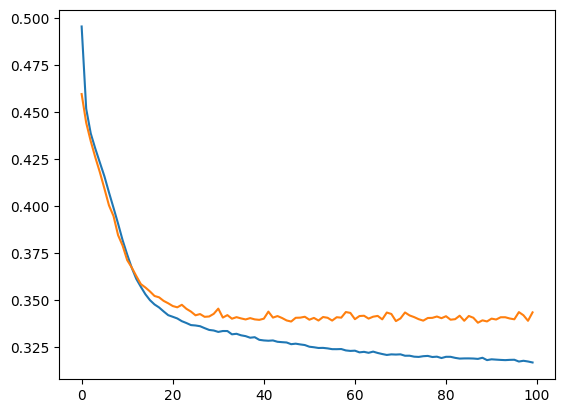

In [35]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

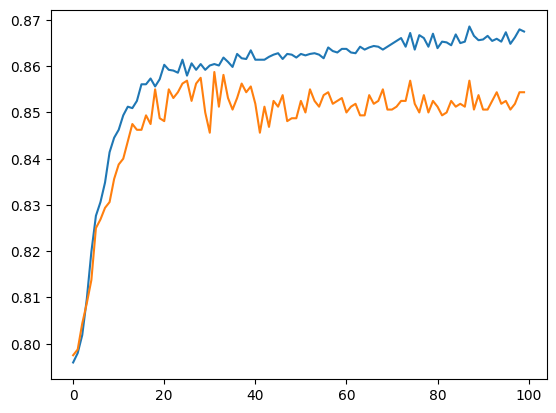

In [36]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])